# 100 — Interactive Betsy wiggle picker

RefraPy is not reading geometry from our SEG-Y headers reliably, so this notebook provides a direct Python fallback for review and picking.

Features:
- loads the Betsy nodal and Geode gathers directly from the catalog;
- uses real receiver positions from `trace_index` / Geode metadata;
- plots normalized wiggles by receiver position, not trace index;
- controls gain, clip, time window, shading mode, and dataset;
- supports click picking on the gather;
- writes picks to CSV and SQLite.

Inputs:
- `shot_events`, `shot_gather_files`, `trace_index`, `geode_events`

Known Betsy IDs:
- nodal: `T1_N2_Refraction2m_T1_N2_E00449`
- Geode: `GEODE_T1_2M_REFRACTION_F3088`

## 1. Configuration

In [1]:
from pathlib import Path
import sqlite3
import json
import traceback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from obspy import read, Stream, UTCDateTime
from scipy.signal import correlate, correlation_lags

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

PROJECT_ROOT = Path("/Volumes/tachyon/LBSSP_DATA")
CATALOG_DB = PROJECT_ROOT / "catalog" / "lbssp_shot_catalog.sqlite"

OUT_ROOT = PROJECT_ROOT / "betsy_gun_alignment_v1" / "interactive_picker"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

BETSY_NODAL_EVENT_ID = "T1_N2_Refraction2m_T1_N2_E00449"
BETSY_GEODE_EVENT_ID = "GEODE_T1_2M_REFRACTION_F3088"

NODAL_COMPONENTS = ["Z", "N", "E"]
GEODE_COMPONENT = None   # Geode channels may not be named *Z.

DEFAULT_TMIN = 0.0
DEFAULT_TMAX = 0.8

print("CATALOG_DB:", CATALOG_DB)
print("OUT_ROOT:", OUT_ROOT)
print("ipywidgets:", HAS_WIDGETS)

CATALOG_DB: /Volumes/tachyon/LBSSP_DATA/catalog/lbssp_shot_catalog.sqlite
OUT_ROOT: /Volumes/tachyon/LBSSP_DATA/betsy_gun_alignment_v1/interactive_picker
ipywidgets: True


## 2. Load catalog rows and waveforms

In [2]:
conn = sqlite3.connect(CATALOG_DB)

shot_events = pd.read_sql("SELECT * FROM shot_events", conn)
shot_gather_files = pd.read_sql("SELECT * FROM shot_gather_files", conn)
trace_index = pd.read_sql("SELECT * FROM trace_index WHERE instrument_system='nodal'", conn)
geode_events = pd.read_sql("SELECT * FROM geode_events", conn)

nodal_event = shot_events[shot_events["event_id"].astype(str).eq(BETSY_NODAL_EVENT_ID)].iloc[0]
geode_event = geode_events[geode_events["geode_event_id"].astype(str).eq(BETSY_GEODE_EVENT_ID)].iloc[0]

nodal_mseed = shot_gather_files[
    (shot_gather_files["event_id"].astype(str).eq(BETSY_NODAL_EVENT_ID)) &
    (shot_gather_files["file_type"].astype(str).str.lower().eq("mseed"))
]["file_path"].iloc[0]

geode_path = geode_event["geode_file_path"]
source_x_m = float(geode_event["source_x_m"])

print("Nodal:", BETSY_NODAL_EVENT_ID)
print(" ", nodal_mseed, Path(nodal_mseed).exists())
print("Geode:", BETSY_GEODE_EVENT_ID)
print(" ", geode_path, Path(geode_path).exists())
print("Source x:", source_x_m)
display(pd.DataFrame([nodal_event]).T)
display(pd.DataFrame([geode_event]).T)

Nodal: T1_N2_Refraction2m_T1_N2_E00449
  /Volumes/tachyon/LBSSP_DATA/nodal_fullnode_shotgathers_v4/T1_N2_Refraction2m/gathers_mseed/T1_N2_Refraction2m_T1_N2_E00449_DPall.mseed True
Geode: GEODE_T1_2M_REFRACTION_F3088
  /Volumes/tachyon/LBSSP_DATA/GEODE_DATA/LBSSP_051826/3088.dat True
Source x: 47.0


,2787
event_id,T1_N2_Refraction2m_T1_N2_E00449
instrument_system,nodal
line,T1
transect,None
survey,T1_2m_refraction
survey_type,geode_stack_metadata
shot_no,42.0
file_no,3088.0
source_x_m,47.0
source_type,hammer


,87
geode_event_id,GEODE_T1_2M_REFRACTION_F3088
instrument_system,geode
source_sheet,T1_2m_Refraction
line,T1
survey,T1_2m_refraction
survey_type,refraction
nodal_timewindow_label,T1_N2_Refraction2m
shot_no,42.0
file_no,3088.0
source_x_m,47.0


## 3. Geometry and gather helpers

In [3]:
def select_component(st, component):
    if component is None:
        return st.copy()
    stc = st.select(channel=f"*{component}").copy()
    return stc


def shift_stream_to_relative_time(st):
    if len(st) == 0:
        return st
    origin = min(tr.stats.starttime for tr in st)
    out = st.copy()
    for tr in out:
        rel = tr.stats.starttime - origin
        tr.stats.starttime = UTCDateTime(0) + rel
    return out


def attach_nodal_geometry(st, event_id, component=None, source_x_m=None):
    geom = trace_index[trace_index["event_id"].astype(str).eq(str(event_id))].copy()
    if component is not None:
        geom = geom[geom["channel"].astype(str).str.endswith(component)].copy()

    geom["receiver_x_m"] = pd.to_numeric(geom["receiver_x_m"], errors="coerce")
    geom = geom.dropna(subset=["receiver_x_m"])

    lookup = {}
    for _, r in geom.iterrows():
        station = str(r.get("station", ""))
        channel = str(r.get("channel", ""))
        network = str(r.get("network", ""))
        location = "" if pd.isna(r.get("location", "")) else str(r.get("location", ""))
        lookup[(station, channel)] = float(r["receiver_x_m"])
        lookup[f"{network}.{station}.{location}.{channel}"] = float(r["receiver_x_m"])
        if "seed_id" in geom.columns and pd.notna(r.get("seed_id")):
            lookup[str(r["seed_id"])] = float(r["seed_id"]) if False else float(r["receiver_x_m"])

    out = st.copy()
    n = 0
    for tr in out:
        x = lookup.get((str(tr.stats.station), str(tr.stats.channel)))
        if x is None:
            x = lookup.get(tr.id)
        if x is None:
            try:
                x = float(str(tr.stats.station)) / 100.0
            except Exception:
                x = None
        if x is not None and np.isfinite(float(x)):
            tr.stats.receiver_x_m = float(x)
            n += 1
        if source_x_m is not None:
            tr.stats.source_x_m = float(source_x_m)
    return out, n


def infer_geode_receiver_xs(geode_row, n_traces):
    first = pd.to_numeric(geode_row.get("receiver_first_m"), errors="coerce")
    last = pd.to_numeric(geode_row.get("receiver_last_m"), errors="coerce")
    spacing = pd.to_numeric(geode_row.get("receiver_spacing_m"), errors="coerce")

    if np.isfinite(first) and np.isfinite(spacing) and spacing != 0:
        return first + np.arange(n_traces) * spacing, "receiver_first_m + spacing"
    if np.isfinite(first) and np.isfinite(last) and n_traces > 1:
        return np.linspace(first, last, n_traces), "linspace(first,last)"
    return np.arange(n_traces, dtype=float), "trace_index_fallback"


def attach_geode_geometry(st, geode_row):
    out = st.copy()
    xs, method = infer_geode_receiver_xs(geode_row, len(out))
    sx = float(geode_row["source_x_m"])
    for tr, x in zip(out, xs):
        tr.stats.receiver_x_m = float(x)
        tr.stats.source_x_m = sx
    return out, method


def preprocess(st, freqmin=5.0, freqmax=150.0):
    out = st.copy()
    for tr in out:
        tr.data = tr.data.astype(np.float64)
        tr.detrend("linear")
        tr.taper(max_percentage=0.02)
        nyq = 0.5 / tr.stats.delta
        if freqmax and freqmax < 0.95 * nyq:
            tr.filter("bandpass", freqmin=freqmin, freqmax=freqmax, corners=4, zerophase=True)
        else:
            tr.filter("highpass", freq=freqmin, corners=4, zerophase=True)
    return out


def stream_to_arrays(st, tmin=0.0, tmax=0.8):
    rows = []
    for i, tr in enumerate(st):
        x = float(getattr(tr.stats, "receiver_x_m", i))
        dt = float(tr.stats.delta)
        t0 = tr.stats.starttime - UTCDateTime(0)
        t = t0 + np.arange(tr.stats.npts) * dt
        grid = np.arange(tmin, tmax + 0.5 * dt, dt)
        y = np.interp(grid, t, tr.data.astype(float), left=np.nan, right=np.nan)
        if np.isfinite(y).sum() < 5:
            continue
        rows.append({"x": x, "t": grid, "y": y, "id": tr.id, "station": tr.stats.station, "channel": tr.stats.channel})
    return sorted(rows, key=lambda r: r["x"])


def normalize_trace(y, clip_percentile=99.0):
    y = np.asarray(y, dtype=float)
    y = y - np.nanmedian(y)
    s = np.nanpercentile(np.abs(y), clip_percentile)
    if not np.isfinite(s) or s <= 0:
        s = np.nanmax(np.abs(y))
    if not np.isfinite(s) or s <= 0:
        s = 1.0
    return np.clip(y / s, -1, 1)

## 4. Load and prepare Betsy streams

In [4]:
raw_nodal = read(str(nodal_mseed))
raw_geode = read(str(geode_path))

nodal_streams = {}
for comp in NODAL_COMPONENTS:
    stc = select_component(raw_nodal, comp)
    stc, n_attached = attach_nodal_geometry(stc, BETSY_NODAL_EVENT_ID, component=comp, source_x_m=source_x_m)
    stc = shift_stream_to_relative_time(stc)
    stc = preprocess(stc)
    nodal_streams[comp] = stc
    print(f"Nodal {comp}: {len(stc)} traces, geometry attached {n_attached}")

geode_stream = select_component(raw_geode, GEODE_COMPONENT)
geode_stream, geode_geom_method = attach_geode_geometry(geode_stream, geode_event)
geode_stream = shift_stream_to_relative_time(geode_stream)
geode_stream = preprocess(geode_stream)
print("Geode:", len(geode_stream), geode_geom_method)
print("Geode channels:", sorted(set(tr.stats.channel for tr in geode_stream)))

Nodal Z: 34 traces, geometry attached 34


/opt/anaconda3/envs/flovopy_plus/lib/python3.12/site-packages/obspy/io/seg2/seg2.py:365: UserWarning: Many companies use custom defined SEG2 header variables. This might cause basic header information reflected in the single traces' stats to be wrong (e.g. recording delays, first sample number, station code names, ..). Please check the complete list of additional unmapped header fields that gets stored in Trace.stats.seg2 and/or the manual of the source of the SEG2 files for fields that might influence e.g. trace start times.
  warnings.warn(WARNING_HEADER)


Nodal N: 34 traces, geometry attached 34
Nodal E: 34 traces, geometry attached 34
Geode: 72 receiver_first_m + spacing
Geode channels: ['']


## 5. Interactive wiggle picker and velocity-line tool

For clicking to work in Jupyter, use an interactive matplotlib backend before running this cell, for example:

```python
%matplotlib widget
```

or, if that is unavailable:

```python
%matplotlib notebook
```

Left-click adds a pick or line point. Right-click deletes the nearest pick/line point for the active mode. In line mode, every two clicked points define a line and velocity is estimated from `v = Δx / Δt`.


Could not switch to %matplotlib widget automatically: RuntimeError("'widget' is not a recognised GUI loop or backend name")
Try running `%matplotlib widget` manually. If unavailable, try `%matplotlib notebook`.


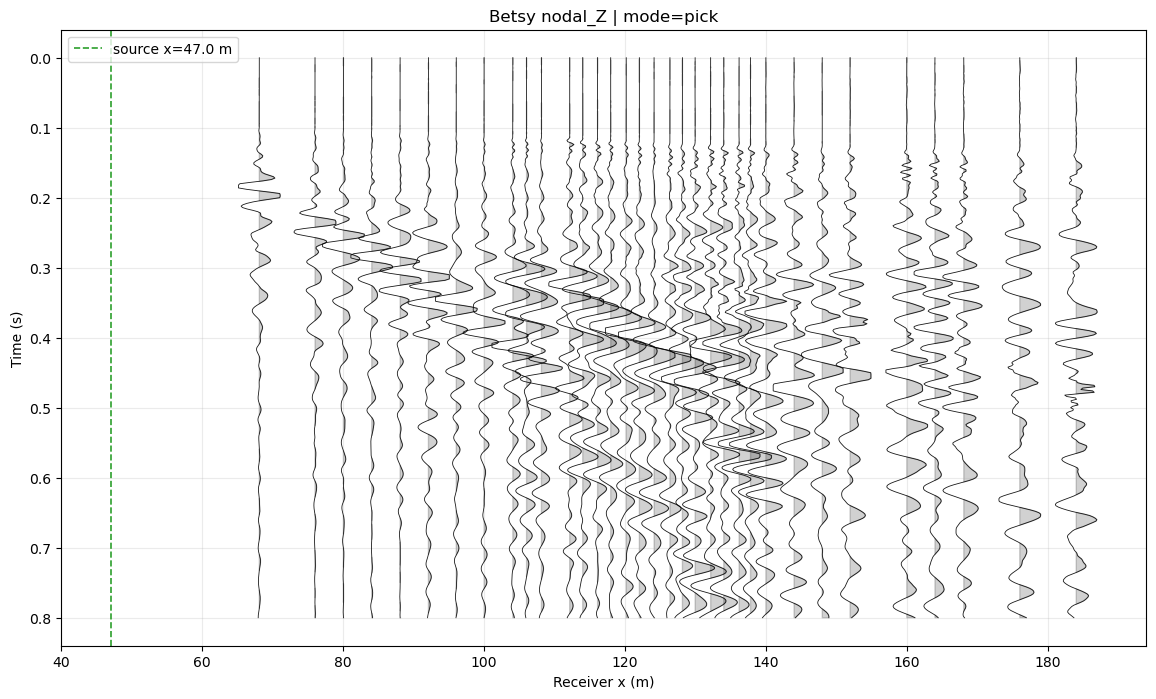

In [8]:

# Try to enable a click-capable matplotlib backend.
# If this fails, run `%matplotlib widget` manually in a separate cell and rerun this cell.
try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception as e:
    print("Could not switch to %matplotlib widget automatically:", repr(e))
    print("Try running `%matplotlib widget` manually. If unavailable, try `%matplotlib notebook`.")

PICKS = []
LINE_POINTS = []
LINES = []

CURRENT = {
    "dataset": "nodal_Z",
    "tmin": DEFAULT_TMIN,
    "tmax": DEFAULT_TMAX,
    "gain": 1.0,
    "trace_scale": 0.75,
    "clip": 99.0,
    "shade": "positive",
    "geode_shift_s": 0.0,
    "mode": "pick",  # pick or line
}

ACTIVE_ROWS = []
ACTIVE_DATASET_FOR_PICK = "nodal_Z"
ACTIVE_GEODE_ROWS = []

_fig = None
_ax = None
_cid = None


def make_combined_rows_nodal_z_geode(tmin=0.0, tmax=0.8, geode_shift_s=0.0):
    nodal_rows = stream_to_arrays(nodal_streams["Z"], tmin=tmin, tmax=tmax)
    geode_rows = stream_to_arrays(geode_stream, tmin=tmin - geode_shift_s, tmax=tmax - geode_shift_s)

    shifted_geode_rows = []
    for r in geode_rows:
        rr = dict(r)
        rr["t"] = rr["t"] + geode_shift_s
        shifted_geode_rows.append(rr)

    return nodal_rows, shifted_geode_rows


def _draw_rows_on_ax(ax, rows, *, color="black", alpha=0.9, gain=1.0, trace_scale=0.75,
                     clip_percentile=99.0, shade="positive", linewidth=0.6):
    if not rows:
        return

    xs = np.array([r["x"] for r in rows], dtype=float)
    ux = np.sort(np.unique(xs[np.isfinite(xs)]))
    dx = np.nanmedian(np.diff(ux)) if len(ux) > 1 else 1.0
    if not np.isfinite(dx) or dx <= 0:
        dx = 1.0

    for r in rows:
        x = r["x"]
        t = r["t"]
        y = normalize_trace(r["y"], clip_percentile=clip_percentile)
        wig = x + gain * trace_scale * dx * y

        ax.plot(wig, t, color=color, linewidth=linewidth, alpha=alpha)

        if shade in ["positive", "both"]:
            ax.fill_betweenx(t, x, wig, where=(wig >= x), color=color, alpha=0.18, interpolate=True)
        if shade in ["negative", "both"]:
            ax.fill_betweenx(t, x, wig, where=(wig < x), color=color, alpha=0.12, interpolate=True)


def nearest_receiver(rows, x):
    xs = np.array([r["x"] for r in rows], dtype=float)
    if len(xs) == 0:
        return None, None
    i = int(np.nanargmin(np.abs(xs - x)))
    return rows[i], i


def estimate_velocity_from_points(p1, p2):
    dx = p2["receiver_x_m"] - p1["receiver_x_m"]
    dt = p2["time_s"] - p1["time_s"]
    if not np.isfinite(dx) or not np.isfinite(dt) or abs(dt) < 1e-9:
        return np.nan
    return dx / dt


def _active_plot_rows(dataset, tmin, tmax, geode_shift_s):
    if dataset.startswith("nodal_"):
        comp = dataset.split("_", 1)[1]
        return stream_to_arrays(nodal_streams[comp], tmin=tmin, tmax=tmax), dataset, []
    if dataset == "geode":
        rows = stream_to_arrays(geode_stream, tmin=tmin - geode_shift_s, tmax=tmax - geode_shift_s)
        shifted = []
        for r in rows:
            rr = dict(r)
            rr["t"] = rr["t"] + geode_shift_s
            shifted.append(rr)
        return shifted, "geode", []
    if dataset == "nodal_Z_plus_geode":
        nodal_rows, geode_rows = make_combined_rows_nodal_z_geode(tmin=tmin, tmax=tmax, geode_shift_s=geode_shift_s)
        return nodal_rows, "nodal_Z", geode_rows
    raise ValueError(dataset)


def redraw():
    global _fig, _ax, _cid, ACTIVE_ROWS, ACTIVE_DATASET_FOR_PICK, ACTIVE_GEODE_ROWS

    dataset = CURRENT["dataset"]
    tmin = CURRENT["tmin"]
    tmax = CURRENT["tmax"]
    gain = CURRENT["gain"]
    trace_scale = CURRENT["trace_scale"]
    clip = CURRENT["clip"]
    shade = CURRENT["shade"]
    geode_shift_s = CURRENT["geode_shift_s"]

    ACTIVE_ROWS, ACTIVE_DATASET_FOR_PICK, ACTIVE_GEODE_ROWS = _active_plot_rows(dataset, tmin, tmax, geode_shift_s)

    if _fig is None or _ax is None:
        _fig, _ax = plt.subplots(figsize=(14, 8))
    else:
        _ax.clear()

    if dataset == "nodal_Z_plus_geode":
        _draw_rows_on_ax(_ax, ACTIVE_ROWS, color="black", alpha=0.9, gain=gain, trace_scale=trace_scale, clip_percentile=clip, shade=shade)
        _draw_rows_on_ax(_ax, ACTIVE_GEODE_ROWS, color="tab:red", alpha=0.55, gain=gain, trace_scale=trace_scale, clip_percentile=clip, shade=shade)
        title = f"Betsy overlay: nodal_Z black + Geode red | shift {geode_shift_s:+.4f} s | mode={CURRENT['mode']}"
    else:
        color = "tab:red" if dataset == "geode" else "black"
        _draw_rows_on_ax(_ax, ACTIVE_ROWS, color=color, alpha=0.9, gain=gain, trace_scale=trace_scale, clip_percentile=clip, shade=shade)
        title = f"Betsy {dataset} | mode={CURRENT['mode']}"

    _ax.axvline(source_x_m, linestyle="--", color="tab:green", linewidth=1.2, label=f"source x={source_x_m:.1f} m")

    # Draw picks
    visible_datasets = [ACTIVE_DATASET_FOR_PICK]
    if dataset == "nodal_Z_plus_geode":
        visible_datasets = ["nodal_Z", "geode"]
    for p in PICKS:
        if p["dataset"] in visible_datasets:
            c = "tab:orange" if p["dataset"].startswith("nodal") else "tab:purple"
            _ax.plot(p["receiver_x_m"], p["pick_time_s"], "o", markersize=5, color=c)
            _ax.text(p["receiver_x_m"], p["pick_time_s"], f"{p['pick_time_s']:.3f}", fontsize=7, color=c)

    # Draw line points and completed lines
    for p in LINE_POINTS:
        if p["dataset"] in visible_datasets:
            _ax.plot(p["receiver_x_m"], p["time_s"], "s", markersize=5, color="tab:blue")
    for ln in LINES:
        if ln["dataset"] in visible_datasets:
            x1, t1, x2, t2 = ln["x1_m"], ln["t1_s"], ln["x2_m"], ln["t2_s"]
            _ax.plot([x1, x2], [t1, t2], "-", color="tab:blue", linewidth=1.8)
            xm = 0.5 * (x1 + x2)
            tm = 0.5 * (t1 + t2)
            _ax.text(xm, tm, f"{ln['velocity_mps']:.0f} m/s", color="tab:blue", fontsize=9,
                     bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

    _ax.invert_yaxis()
    _ax.set_xlabel("Receiver x (m)")
    _ax.set_ylabel("Time (s)")
    _ax.set_title(title)
    _ax.grid(True, alpha=0.25)
    _ax.legend(loc="best")

    if _cid is None:
        _cid = _fig.canvas.mpl_connect("button_press_event", onclick)

    _fig.canvas.draw_idle()
    plt.show()


def onclick(event):
    if event.inaxes != _ax or event.xdata is None or event.ydata is None:
        return

    dataset = CURRENT["dataset"]
    mode = CURRENT["mode"]

    rows_to_pick = ACTIVE_ROWS
    dataset_to_pick = ACTIVE_DATASET_FOR_PICK

    # In overlay mode, ctrl-click or middle-click applies to Geode instead of nodal_Z.
    if dataset == "nodal_Z_plus_geode":
        if event.button == 2 or getattr(event, "key", None) in ["control", "ctrl"]:
            rows_to_pick = ACTIVE_GEODE_ROWS
            dataset_to_pick = "geode"

    r, idx = nearest_receiver(rows_to_pick, event.xdata)
    if r is None:
        print("No active traces to pick.")
        return

    x_pick = float(r["x"])
    t_pick = float(event.ydata)

    if mode == "pick":
        if event.button == 3 or getattr(event, "key", None) == "shift":
            subset = [
                (i, p) for i, p in enumerate(PICKS)
                if p["dataset"] == dataset_to_pick and abs(p["receiver_x_m"] - x_pick) < 0.51
            ]
            if subset:
                j, _ = min(subset, key=lambda ip: abs(ip[1]["pick_time_s"] - t_pick))
                removed = PICKS.pop(j)
                print(f"Deleted pick: {removed}")
        else:
            pick = {
                "dataset": dataset_to_pick,
                "receiver_x_m": x_pick,
                "pick_time_s": t_pick,
                "trace_index": int(idx),
                "trace_id": r["id"],
                "station": r["station"],
                "channel": r["channel"],
                "source_x_m": source_x_m,
                "event_id": BETSY_NODAL_EVENT_ID if dataset_to_pick.startswith("nodal") else BETSY_GEODE_EVENT_ID,
                "display_mode": dataset,
                "geode_shift_s": CURRENT["geode_shift_s"] if dataset_to_pick == "geode" else 0.0,
            }
            PICKS.append(pick)
            print(f"Added pick: {dataset_to_pick} x={x_pick:.2f} t={t_pick:.4f} | total picks={len(PICKS)}")

    elif mode == "line":
        if event.button == 3 or getattr(event, "key", None) == "shift":
            if LINES:
                removed = LINES.pop()
                print(f"Deleted last line: {removed}")
            elif LINE_POINTS:
                removed = LINE_POINTS.pop()
                print(f"Deleted last line point: {removed}")
        else:
            point = {
                "dataset": dataset_to_pick,
                "receiver_x_m": x_pick,
                "time_s": t_pick,
                "trace_index": int(idx),
                "trace_id": r["id"],
                "source_x_m": source_x_m,
                "event_id": BETSY_NODAL_EVENT_ID if dataset_to_pick.startswith("nodal") else BETSY_GEODE_EVENT_ID,
            }
            LINE_POINTS.append(point)
            print(f"Added line point: {dataset_to_pick} x={x_pick:.2f} t={t_pick:.4f}")

            # If last two points are for the same dataset, make a line.
            if len(LINE_POINTS) >= 2:
                p1, p2 = LINE_POINTS[-2], LINE_POINTS[-1]
                if p1["dataset"] == p2["dataset"]:
                    v = estimate_velocity_from_points(p1, p2)
                    line = {
                        "dataset": p1["dataset"],
                        "x1_m": p1["receiver_x_m"],
                        "t1_s": p1["time_s"],
                        "x2_m": p2["receiver_x_m"],
                        "t2_s": p2["time_s"],
                        "dx_m": p2["receiver_x_m"] - p1["receiver_x_m"],
                        "dt_s": p2["time_s"] - p1["time_s"],
                        "velocity_mps": v,
                        "abs_velocity_mps": abs(v) if np.isfinite(v) else np.nan,
                        "source_x_m": source_x_m,
                    }
                    LINES.append(line)
                    # remove the two pending points
                    LINE_POINTS.pop()
                    LINE_POINTS.pop()
                    print(f"Added velocity line: v={v:.1f} m/s, |v|={abs(v):.1f} m/s")

    redraw()


def update_current_and_redraw(dataset, tmin, tmax, gain, trace_scale, clip, shade, geode_shift_s, mode):
    CURRENT.update({
        "dataset": dataset,
        "tmin": float(tmin),
        "tmax": float(tmax),
        "gain": float(gain),
        "trace_scale": float(trace_scale),
        "clip": float(clip),
        "shade": shade,
        "geode_shift_s": float(geode_shift_s),
        "mode": mode,
    })
    redraw()


if HAS_WIDGETS:
    dataset_widget = widgets.Dropdown(
        options=["nodal_Z", "nodal_N", "nodal_E", "geode", "nodal_Z_plus_geode"],
        value="nodal_Z",
        description="Dataset",
    )
    mode_widget = widgets.ToggleButtons(options=["pick", "line"], value="pick", description="Mode")
    tmin_widget = widgets.FloatText(value=DEFAULT_TMIN, description="tmin")
    tmax_widget = widgets.FloatText(value=DEFAULT_TMAX, description="tmax")
    gain_widget = widgets.FloatSlider(value=1.0, min=0.1, max=15.0, step=0.1, description="gain")
    scale_widget = widgets.FloatSlider(value=0.75, min=0.1, max=4.0, step=0.05, description="trace scale")
    clip_widget = widgets.FloatSlider(value=99.0, min=90.0, max=100.0, step=0.5, description="clip %")
    shade_widget = widgets.Dropdown(options=["none", "positive", "negative", "both"], value="positive", description="shade")
    geode_shift_widget = widgets.FloatText(value=0.0, description="Geode shift s")

    redraw_button = widgets.Button(description="Redraw", button_style="primary")
    clear_picks_button = widgets.Button(description="Clear picks")
    clear_lines_button = widgets.Button(description="Clear lines")

    def on_redraw(_):
        update_current_and_redraw(
            dataset_widget.value,
            tmin_widget.value,
            tmax_widget.value,
            gain_widget.value,
            scale_widget.value,
            clip_widget.value,
            shade_widget.value,
            geode_shift_widget.value,
            mode_widget.value,
        )

    def on_clear_picks(_):
        PICKS.clear()
        print("Cleared picks.")
        redraw()

    def on_clear_lines(_):
        LINE_POINTS.clear()
        LINES.clear()
        print("Cleared lines.")
        redraw()

    redraw_button.on_click(on_redraw)
    clear_picks_button.on_click(on_clear_picks)
    clear_lines_button.on_click(on_clear_lines)

    ui = widgets.VBox([
        widgets.HBox([dataset_widget, mode_widget, shade_widget]),
        widgets.HBox([tmin_widget, tmax_widget, geode_shift_widget]),
        widgets.HBox([gain_widget, scale_widget, clip_widget]),
        widgets.HBox([redraw_button, clear_picks_button, clear_lines_button]),
    ])

    display(ui)
    update_current_and_redraw(
        dataset_widget.value,
        tmin_widget.value,
        tmax_widget.value,
        gain_widget.value,
        scale_widget.value,
        clip_widget.value,
        shade_widget.value,
        geode_shift_widget.value,
        mode_widget.value,
    )
else:
    print("ipywidgets not available. Use update_current_and_redraw(...) manually.")
    update_current_and_redraw("nodal_Z", DEFAULT_TMIN, DEFAULT_TMAX, 1.0, 0.75, 99.0, "positive", 0.0, "pick")


## 6. Static combined overlay plot

In [6]:
def plot_overlay_nodal_geode(comp="Z", geode_shift_s=0.0, tmin=0.0, tmax=0.8, gain=1.0, shade="positive"):
    nodal_rows = stream_to_arrays(nodal_streams[comp], tmin=tmin, tmax=tmax)
    geode_rows = stream_to_arrays(geode_stream, tmin=tmin - geode_shift_s, tmax=tmax - geode_shift_s)

    # Apply time shift to Geode rows for plotting.
    shifted_geode_rows = []
    for r in geode_rows:
        rr = dict(r)
        rr["t"] = rr["t"] + geode_shift_s
        shifted_geode_rows.append(rr)

    fig, ax = plt.subplots(figsize=(14, 8))

    plot_wiggle_arrays(
        nodal_rows,
        title=f"Betsy Gun overlay: nodal {comp} black, Geode red | Geode shift {geode_shift_s:+.4f} s",
        source_x_m=source_x_m,
        gain=gain,
        shade="none",
        color="black",
        picks=None,
        figsize=(14, 8),
    )
    plt.close()

    # Redo on shared axis.
    fig, ax = plt.subplots(figsize=(14, 8))
    for rows, color, alpha, label in [
        (nodal_rows, "black", 0.9, f"nodal {comp}"),
        (shifted_geode_rows, "tab:red", 0.55, "Geode shifted"),
    ]:
        xs = np.array([r["x"] for r in rows], dtype=float)
        ux = np.sort(np.unique(xs[np.isfinite(xs)]))
        dx = np.nanmedian(np.diff(ux)) if len(ux) > 1 else 1.0
        if not np.isfinite(dx) or dx <= 0:
            dx = 1.0
        for r in rows:
            y = normalize_trace(r["y"])
            wig = r["x"] + gain * 0.75 * dx * y
            ax.plot(wig, r["t"], color=color, alpha=alpha, linewidth=0.6)

    ax.axvline(source_x_m, linestyle="--", color="tab:green", linewidth=1.2)
    ax.invert_yaxis()
    ax.set_xlabel("Receiver x (m)")
    ax.set_ylabel("Time (s)")
    ax.set_title(f"Betsy Gun overlay: nodal {comp} + Geode shifted {geode_shift_s:+.4f} s")
    ax.grid(True, alpha=0.25)
    plt.show()
    return fig, ax

# Example:
# plot_overlay_nodal_geode(comp="Z", geode_shift_s=0.0, gain=2.0)

## 7. Save picks

In [7]:

def save_picks_and_lines():
    picks_df = pd.DataFrame(PICKS)
    lines_df = pd.DataFrame(LINES)

    picks_csv = OUT_ROOT / "betsy_interactive_picks.csv"
    lines_csv = OUT_ROOT / "betsy_interactive_velocity_lines.csv"

    picks_df.to_csv(picks_csv, index=False)
    lines_df.to_csv(lines_csv, index=False)

    with sqlite3.connect(CATALOG_DB) as conn:
        conn.execute('DROP TABLE IF EXISTS betsy_interactive_picks')
        conn.execute('DROP TABLE IF EXISTS betsy_interactive_velocity_lines')

        if len(picks_df.columns) == 0:
            picks_df = pd.DataFrame(columns=["dataset", "receiver_x_m", "pick_time_s", "event_id"])
        if len(lines_df.columns) == 0:
            lines_df = pd.DataFrame(columns=["dataset", "x1_m", "t1_s", "x2_m", "t2_s", "velocity_mps"])

        picks_df.to_sql("betsy_interactive_picks", conn, if_exists="fail", index=False)
        lines_df.to_sql("betsy_interactive_velocity_lines", conn, if_exists="fail", index=False)
        conn.commit()

    print("Saved picks:", picks_csv)
    print("Saved lines:", lines_csv)
    display(picks_df)
    display(lines_df)
    return picks_df, lines_df

# Run after picking/line marking:
# picks_df, lines_df = save_picks_and_lines()

# Backward-compatible alias:
def save_picks():
    return save_picks_and_lines()[0]
